# 2D случай

## Движение к заданным точкам, градиентный спуск

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
class Robot:
    def __init__(
            self,
            link_lengths=[50, 40, 30, 30],
            theta_array=[np.pi/2, 0, 0, 0],
            link_widths = None
        ):
        self._Thetas = None
        self.links = np.asarray(link_lengths)
        if link_widths is None:
            self.link_width = np.ones_like(self.links) * 10
        else:
            self.link_width = np.asarray(link_widths)
        self.set_pose(theta_array)
        
    def forward_kinematics(self, theta_array, change_robot_conf=False) -> np.ndarray:
        if change_robot_conf:
            self.set_pose(theta_array)
        f_fk = np.zeros((self.links.size, 2))
        phi = 0
        J_m = np.zeros(2)
        for i in range(self.links.size):
            phi += theta_array[i]
            J_m += self.links[i] * np.array([np.cos(phi), np.sin(phi)])
            f_fk[i] = J_m
        return f_fk

    def column_jacobi(self, joint_num, col_num) -> np.array:
        total_sum = np.zeros(2)
        phi = np.sum(self._Thetas[:col_num])
        for i in range(col_num, joint_num+1):
            phi += self._Thetas[i]
            total_sum += self.links[i] * np.array([-np.sin(phi), np.cos(phi)])
        return total_sum
    
    def jacobi(self, joint_num) -> np.ndarray:
        jacobi_matrix = np.zeros((2, self.links.size))
        for i in range(self.links.size):
            jacobi_matrix[:, i] = self.column_jacobi(joint_num, i)
        return jacobi_matrix

    def set_pose(self, theta_array) -> None:
        self._Thetas = np.asarray(theta_array)
        assert (self.links.size == self._Thetas.size) and (self.link_width.size == self._Thetas.size), "Size of theta_array must be equal to link's sizes!"
    
    def get_pose(self) -> np.array:
        return self._Thetas

In [3]:
def loss_and_grad(robot, theta, target_indices, target_points):
    joints = robot.forward_kinematics(theta, change_robot_conf=True)

    loss = 0.0
    grad = np.zeros_like(theta, dtype=float)

    for joint_idx, target in zip(target_indices, target_points):
        residual = joints[joint_idx] - target
        Jacobi = robot.jacobi(joint_idx)

        loss += residual.T @ residual
        grad += 2 * Jacobi.T @ residual

    return loss, grad

def solve_regression(
    robot,
    target_indices,
    target_points,
    theta_init=None,
    lr=1e-5,
    max_iter=10000,
    tol=1e-6,
):
    if theta_init is None:
        theta = robot.get_pose().copy()
    else:
        theta = np.asarray(theta_init, dtype=float).copy()

    history = []

    for step in range(max_iter):
        loss, grad = loss_and_grad(robot, theta, target_indices, target_points)
        history.append(loss)

        if np.linalg.norm(grad) < tol:
            break

        theta -= lr * grad
        theta = (theta + np.pi) % (2 * np.pi) - np.pi

    robot.set_pose(theta)
    return theta, history

In [4]:
def robot_points(robot, theta):
    joints = robot.forward_kinematics(theta, change_robot_conf=False)
    return np.vstack([np.zeros(2), joints])


def plot_robot_solution(
    robot,
    theta_start,
    theta_final,
    target_indices,
    target_points,
    filename="robot_solution.png"
):
    theta_start = np.asarray(theta_start, dtype=float)
    theta_final = np.asarray(theta_final, dtype=float)
    target_indices = np.asarray(target_indices, dtype=int)
    target_points = np.asarray(target_points, dtype=float)

    start_points = robot_points(robot, theta_start)
    final_points = robot_points(robot, theta_final)

    fig, ax = plt.subplots()

    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, linewidth=0.3)

    all_points = np.vstack([start_points, final_points, target_points])
    margin = max(10.0, 0.1 * np.sum(robot.links))

    ax.set_xlim(all_points[:, 0].min() - margin, all_points[:, 0].max() + margin)
    ax.set_ylim(all_points[:, 1].min() - margin, all_points[:, 1].max() + margin)

    ax.plot(
        start_points[:, 0],
        start_points[:, 1],
        linestyle="--",
        color="#dc2626",
        linewidth=3,
        marker="o",
        markersize=7,
        markerfacecolor="white",
        markeredgecolor="#dc2626",
        markeredgewidth=2,
        label="initial pose",
        zorder=3,
    )

    ax.plot(
        final_points[:, 0],
        final_points[:, 1],
        linestyle="-",
        color="#2563eb",
        linewidth=4,
        marker="o",
        markersize=7,
        markerfacecolor="white",
        markeredgecolor="#111827",
        markeredgewidth=2,
        label="final pose",
        zorder=4,
    )

    ax.scatter(
        target_points[:, 0],
        target_points[:, 1],
        marker="x",
        s=130,
        linewidths=3,
        color="#7c3aed",
        label="targets",
        zorder=5,
    )

    for joint_idx, target in zip(target_indices, target_points):
        ax.text(
            target[0],
            target[1],
            f"  G{joint_idx + 1}",
            color="#7c3aed",
            fontsize=11,
            weight="bold",
        )

    ax.set_title("Manipulator solution")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()

    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()


def plot_loss(loss_history, filename="loss.png"):
    fig, ax = plt.subplots(figsize=(8, 4))

    ax.plot(loss_history, color="#16a34a", linewidth=1.5)

    ax.set_title("Loss")
    ax.set_xlabel("iteration")
    ax.set_ylabel("loss")

    ax.grid(True, linewidth=0.5)

    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

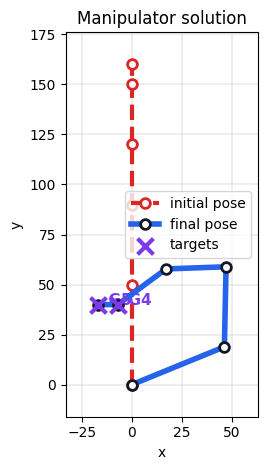

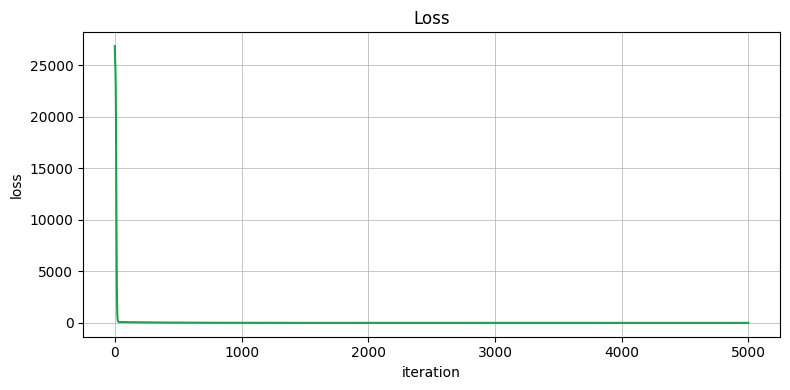

In [5]:
robot = Robot(
    link_lengths=[50, 40, 30, 30, 10],
    theta_array=[np.pi / 2, 0, 0, 0, 0],
)

theta_start = robot.get_pose().copy()

target_indices = [3, 4]
target_points = np.array([
    [-7, 40],
    [-17, 40]
])

theta_final, loss_history = solve_regression(
    robot,
    target_indices,
    target_points,
    theta_init=theta_start,
    lr=1e-5,
    max_iter=5000
)

plot_robot_solution(
    robot,
    theta_start,
    theta_final,
    target_indices,
    target_points,
    "python_data/robot_solution1.png"
)

plot_loss(loss_history, "python_data/loss1.png")

## Итеративное приближение к заданным точкам, обучение MLP

In [7]:
class Map:
    def __init__(self, disc_map_size=(200, 200), discretization=1):
        self.robot = np.empty((0, 2), dtype=int)
        self.obstacles = np.empty((0, 2), dtype=int)
        self.scene = np.zeros(shape=disc_map_size)
        self.discretization = discretization

    def get_robot(self, robot: Robot) -> None:
        theta = robot.get_pose()
        joints = robot.forward_kinematics(theta, change_robot_conf=False)

        points = np.vstack([np.zeros(2), joints])
        occupied = []
        h, w_map = self.scene.shape
        cell = self.discretization

        origin = np.array([
            w_map * cell / 2,
            h * cell / 2
        ])

        def world_to_grid(p):
            x = p[0] + origin[0]
            y = origin[1] - p[1]

            j = int(x // cell)
            i = int(y // cell)

            return i, j

        for link_id in range(len(points) - 1):
            A = points[link_id]
            B = points[link_id + 1]

            d = B - A
            L = np.linalg.norm(d)

            if L == 0:
                continue

            u = d / L
            n = np.array([-u[1], u[0]])

            link_width = robot.link_width[link_id]

            corners = np.array([
                A + n * link_width / 2,
                A - n * link_width / 2,
                B + n * link_width / 2,
                B - n * link_width / 2,
            ])

            min_x = corners[:, 0].min()
            max_x = corners[:, 0].max()
            min_y = corners[:, 1].min()
            max_y = corners[:, 1].max()

            top_left = world_to_grid(np.array([min_x, max_y]))
            bottom_right = world_to_grid(np.array([max_x, min_y]))

            i_min = max(0, min(top_left[0], bottom_right[0]))
            i_max = min(h - 1, max(top_left[0], bottom_right[0]))
            j_min = max(0, min(top_left[1], bottom_right[1]))
            j_max = min(w_map - 1, max(top_left[1], bottom_right[1]))

            for i in range(i_min, i_max + 1):
                for j in range(j_min, j_max + 1):
                    x = j * cell + cell / 2 - origin[0]
                    y = origin[1] - (i * cell + cell / 2)
                    C = np.array([x, y])

                    v = C - A
                    s = np.dot(v, u)
                    r = np.dot(v, n)

                    if 0 <= s <= L and abs(r) <= link_width / 2:
                        occupied.append([i, j])

        self.robot = np.unique(np.array(occupied, dtype=int), axis=0)

    def set_obstacles(self, obstacle_idxs: np.ndarray) -> None:
        self.obstacles = np.asarray(obstacle_idxs, dtype=int)

    def set_interception(self, idx):
        if self.scene[idx[0], idx[1]] == 0:
            self.scene[idx[0], idx[1]] = 1
        else:
            self.scene[idx[0], idx[1]] = -1 

    def make_map(self) -> None:
        self.scene = np.zeros_like(self.scene)
        for (i,j) in self.obstacles:
            self.scene[i, j] = 1
        for ij in self.robot:
            self.set_interception(ij)

    def get_interceptions(self) -> np.ndarray:
        interceptions = []
        for i in range(self.scene.shape[0]):
            for j in range(self.scene.shape[1]):
                if self.scene[i, j] == -1:
                    interceptions.append([i, j])
        return np.array(interceptions, dtype=int)

    def get_obstacles(self) -> np.ndarray:
        return self.obstacles.copy()

    def get_free_space(self) -> np.ndarray:
        free_space = []
        for i in range(self.scene.shape[0]):
            for j in range(self.scene.shape[1]):
                if self.scene[i, j] == 0:
                    free_space.append([i, j])
        return np.array(free_space, dtype=int)